<a href="https://colab.research.google.com/github/sparsh41/AI-Research-Projects/blob/main/Emojify_Face.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Opencv

In [53]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python
!pip install opencv-python-headless==4.10.0.84

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
Found existing installation: opencv-contrib-python 4.14.0.94
Uninstalling opencv-contrib-python-4.14.0.94:
  Successfully uninstalled opencv-contrib-python-4.14.0.94
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00


***Modules Used***


*   Pandas - This library helps to load the data frame in a 2D array format and has multiple functions to perform analysis tasks in one go.
* Numpy - Numpy arrays are very fast and can perform large computations in a very short time.
* Matplotlib - This library is used to draw visualizations.
* Sklearn - This module contains multiple libraries having pre-implemented functions to perform tasks from data preprocessing to model development and evaluation.
* OpenCV - This is an open-source library mainly focused on image processing and handling.
* Tensorflow - This is an open-source library that is used for Machine Learning and Artificial intelligence and provides a range of functions to achieve complex functionalities with single lines of code.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from PIL import Image

from sklearn import metrics

import cv2
import os

from glob import glob

import tensorflow as tf
from tensorflow import keras
from keras import layers

from google.colab.patches import cv2_imshow

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving emojis.zip to emojis.zip


In [2]:
!unzip -o emojis.zip

Archive:  emojis.zip
  inflating: emojis/angry.jpg        
  inflating: emojis/disgust.jpg      
  inflating: emojis/fear.jpg         
  inflating: emojis/happy.jpg        
  inflating: emojis/neutral.jpg      
  inflating: emojis/sad.jpg          
  inflating: emojis/surprise.jpg     
  inflating: emojis/znone.jpg        


In [3]:
!ls emojis

angry.jpg    fear.jpg	neutral.jpg  surprise.jpg
disgust.jpg  happy.jpg	sad.jpg      znone.jpg


**Download the Dataset from kagglehub**

https://www.kaggle.com/datasets/msambare/fer2013/data?select=train

The dataset contains two zipped folders: test and train. For our purposes, we will be using the 'train' directory to train the model.

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [5]:
train_dir = "/kaggle/input/fer2013/train" # Directory containing the training data
test_dir = "/kaggle/input/fer2013/test"  # Directory containing the validation data

The dataset contains 7 categories of emotions.

In [6]:
path = train_dir
classes = os.listdir(path)
classes

['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']

Plot of the pictures relating to the 7 classes we have in this dataset

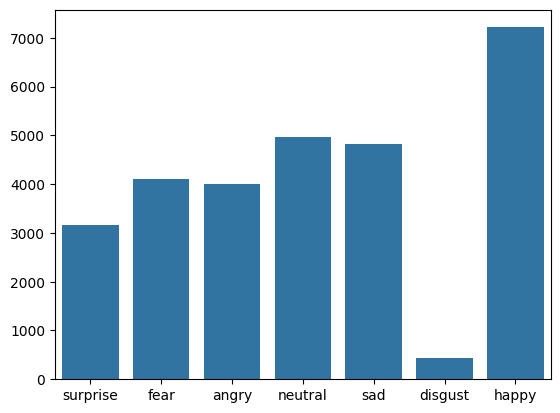

In [7]:
count = []
for cat in classes:
  count.append(len(os.listdir(f'{path}/{cat}')))

sb.barplot(x=classes, y=count)
plt.show()

#**Model Development**

From this step onward we will use the TensorFlow library to build our CNN model. Keras framework of the tensor flow library contains all the functionalities that one may need to define the architecture of a Convolutional Neural Network and train it on the data.

##### *CNN (Convolutional Neural Network)* - Recieves and input image, goes through multiple layers, which include filtering and cdownsampling to categrize it

## Model Architecture
We will implement a Sequential model which will contain the following parts:

* Three Convolutional Layers followed by MaxPooling Layers.
* The Flatten layer to flatten the output of the convolutional layer.
* Then we will have two fully connected layers followed by the output of the flattened layer.
* We have included some BatchNormalization layers to enable stable and fast training and a Dropout layer before the final layer to avoid any possibility of overfitting.
* The final layer is the output layer which outputs soft probabilities for the seven classes.

In [8]:
train_gen = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    label_mode='categorical'
)

val_gen = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    label_mode='categorical'
)

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.05),
    keras.layers.RandomZoom(0.05)
])

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


Store the labels and which images belong to the classes

This should be the same as the classes we defined earlier when preprocessing. If the code runs correctly, we know that our rescale and generation worked correctly

In [9]:
emotions = list(train_gen.class_names)
emotions

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Define the model's architecture

##**Switch to T4 GPU before running cell**

In [10]:
model = keras.models.Sequential([
    # Data augmentation
    data_augmentation,

    # Normalize pixels
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(7, activation='softmax')
])

##Now, we have to compile the model
###While compiling a model we provide these three essential parameters:

optimizer - This is the method that helps to optimize the cost function by using gradient descent. ADAM (Adaptive Moment Estimation) - combine momentum and learning rates

loss - The loss function by which we monitor whether the model is improving with training or not.

metrics - This helps to evaluate the model by predicting the training and the validation data.

In [11]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics=['accuracy']
)

###Callback

Callbacks are used to check whether the model is improving with each epoch or not. If not then what are the necessary steps to be taken like ReduceLROnPlateau decreases learning rate further. Even then if model performance is not improving then training will be stopped by EarlyStopping. We can also define some custom callbacks to stop training in between if the desired results have been obtained early.

In [12]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)

lr = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-6, verbose=1)

Weighting classes because of the range of images

In [13]:
class_weights = {
    0: 1.0,
    1: 3.0,
    2: 1.0,
    3: 0.7,
    4: 0.9,
    5: 0.9,
    6: 1.2
}

Train the model

In [14]:
history = model.fit(train_gen,
                    validation_data = val_gen,
                    epochs = 50,
                    class_weight=class_weights,
                    verbose = 1,
                    callbacks = [es, lr])

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.2710 - loss: 1.8889 - val_accuracy: 0.3150 - val_loss: 1.7552 - learning_rate: 0.0010
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.4034 - loss: 1.5074 - val_accuracy: 0.4844 - val_loss: 1.3547 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.4667 - loss: 1.3705 - val_accuracy: 0.5050 - val_loss: 1.2837 - learning_rate: 0.0010
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.4952 - loss: 1.3163 - val_accuracy: 0.4785 - val_loss: 1.4117 - learning_rate: 0.0010
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.5124 - loss: 1.2666 - val_accuracy: 0.5266 - val_loss: 1.2444 - learning_rate: 0.0010
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5189 - loss: 1.2391 - val_accuracy: 0.5291 - val_loss: 1.2550 - learning_rate: 0.0010
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.5385 - l

##Analyze Performance

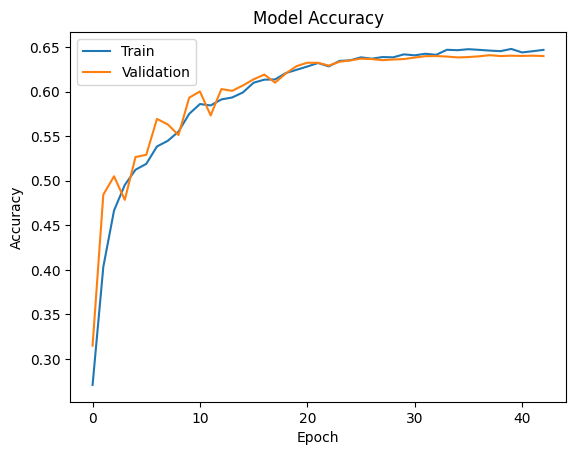

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

val_gen = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    label_mode='categorical',
    shuffle=False
)

predictions = model.predict(val_gen)

y_pred = np.argmax(predictions, axis=1)

y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for images, labels in val_gen
])

print(classification_report(
    y_true,
    y_pred,
    target_names=val_gen.class_names
))

Found 7178 files belonging to 7 classes.
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
              precision    recall  f1-score   support

       angry       0.57      0.57      0.57       958
     disgust       0.57      0.59      0.58       111
        fear       0.51      0.37      0.43      1024
       happy       0.87      0.83      0.85      1774
     neutral       0.54      0.70      0.61      1233
         sad       0.53      0.47      0.50      1247
    surprise       0.73      0.81      0.77       831

    accuracy                           0.64      7178
   macro avg       0.62      0.62      0.61      7178
weighted avg       0.64      0.64      0.64      7178



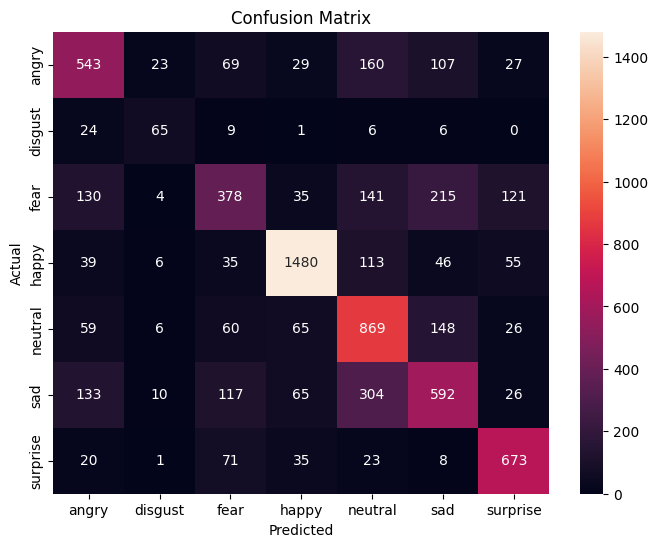

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sb.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=val_gen.class_names,
    yticklabels=val_gen.class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

This is part two of this project where we will predict expressions on a person's face and show an emoji based on that in real-time. To detect the face in a video feed we will use haar_cascade_classifier.

Helper function to plot the image

In [18]:
def plot_image(img, emoj):
    wmin = 256
    hmin = 256

    emoj = cv2.resize(emoj, (wmin, hmin))
    img = cv2.resize(img, (wmin, hmin))
    cv2_imshow(img)
    cv2_imshow(emoj)

Now we have to get access to the camera to get a video capture. To predict the emoji, we will use the haar_cascade_classifier.

In [19]:
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
        const div = document.createElement('div');

        const capture = document.createElement('button');
        capture.textContent = 'Capture';
        capture.style.fontSize = '20px';
        capture.style.padding = '10px';

        div.appendChild(capture);

        const video = document.createElement('video');
        video.style.display = 'block';
        video.style.width = '640px';

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        document.body.appendChild(div);
        div.appendChild(video);

        video.srcObject = stream;
        await video.play();

        google.colab.output.setIframeHeight(
            document.documentElement.scrollHeight,
            true
        );

        // Wait for Capture button
        await new Promise((resolve) => {
            capture.onclick = resolve;
        });

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(
            video,
            0,
            0,
            canvas.width,
            canvas.height
        );

        // Stop webcam
        stream.getVideoTracks()[0].stop();

        div.remove();

        return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)

    data = eval_js('takePhoto({})'.format(quality))

    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

Test web capture

<IPython.core.display.Javascript object>

Saved: photo.jpg


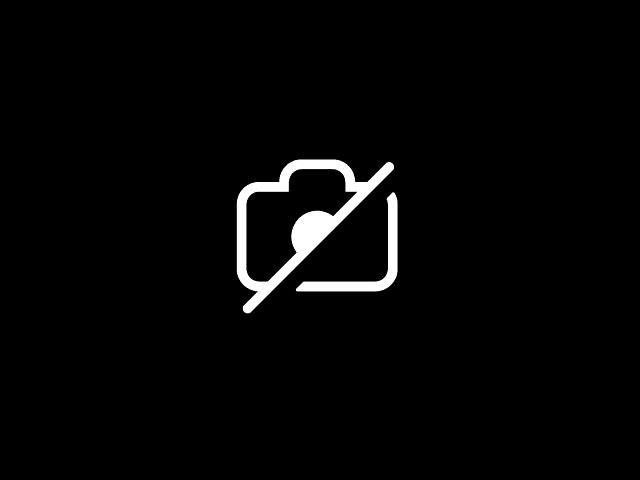

In [62]:

from IPython.display import Image

filename = take_photo()

print("Saved:", filename)

display(Image(filename))

#**FINAL EXECUTION**

# #WEDIDIT


<IPython.core.display.Javascript object>

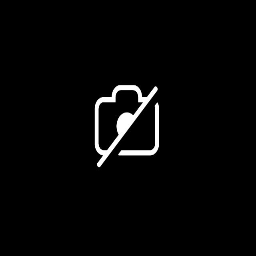

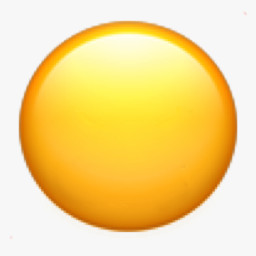

No face detected.


In [63]:
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)


# Take photo
filename = take_photo()

# Read photo
frame = cv2.imread(filename)

# Resize
img = cv2.resize(frame, (256, 256))


# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


# Detect faces
faces = face_cascade.detectMultiScale(gray)


if len(faces) > 0:

    for (x, y, w, h) in faces:

        # Crop face
        face = gray[y:y+h, x:x+w]


        # Resize face
        face = cv2.resize(face, (48, 48))

        # Prepare for model
        face = np.expand_dims(face, axis=-1)
        face = np.expand_dims(face, axis=0)

        # Predict
        pred = model.predict(face, verbose=0)
        idx = pred.argmax(axis=-1)[0]


        # Load emoji
        emoji_path = f'emojis/{emotions[idx]}.jpg'
        emoj = cv2.imread(emoji_path)

        # display
        plot_image(img, emoj)

else:
    emoj = cv2.imread('emojis/znone.jpg')
    plot_image(img, emoj)
    print("No face detected.")

Diagnosing Errors

Cascade loaded: True


<IPython.core.display.Javascript object>

Filename: photo.jpg
Frame: [[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]
Frame is None: False
Frame shape: (480, 640, 3)
Resized image shape: (256, 256, 3)
Gray shape: (256, 256)
Faces detected: 0


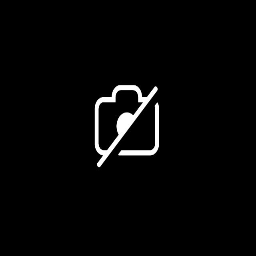

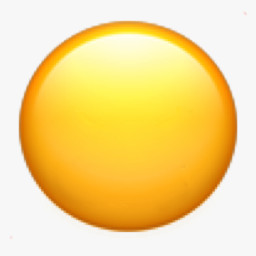

No face detected.


In [65]:
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)

print("Cascade loaded:", not face_cascade.empty())


# Take photo
filename = take_photo()

print("Filename:", filename)

# Read photo
frame = cv2.imread(filename)


print("Frame:", frame)
print("Frame is None:", frame is None)

if frame is None:
    raise ValueError("OpenCV could not read the captured webcam image.")

print("Frame shape:", frame.shape)

# Resize
img = cv2.resize(frame, (256, 256))

print("Resized image shape:", img.shape)

# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Gray shape:", gray.shape)

# Detect faces
faces = face_cascade.detectMultiScale(gray)

print("Faces detected:", len(faces))

if len(faces) > 0:

    for (x, y, w, h) in faces:

        print("Face coordinates:", x, y, w, h)

        # Crop face
        face = gray[y:y+h, x:x+w]

        print("Face crop shape:", face.shape)

        if face.size == 0:
            print("ERROR: Face crop is empty!")
            continue

        # Resize face
        face = cv2.resize(face, (48, 48))

        # Prepare for model
        face = np.expand_dims(face, axis=-1)
        face = np.expand_dims(face, axis=0)

        # Predict
        pred = model.predict(face, verbose=0)
        idx = pred.argmax(axis=-1)[0]

        print("Predicted emotion:", emotions[idx])

        # Load emoji
        emoji_path = f'emojis/{emotions[idx]}.jpg'
        emoj = cv2.imread(emoji_path)

        print("Emoji path:", emoji_path)
        print("Emoji loaded:", emoj is not None)

        if emoj is None:
            raise ValueError(f"Could not load emoji: {emoji_path}")

        plot_image(img, emoj)

else:

    emoj = cv2.imread('emojis/znone.jpg')

    if emoj is None:
        raise ValueError("Could not load znone.jpg")

    plot_image(img, emoj)
    print("No face detected.")